# W.01: The Normal Distribution

\pagetab{W.01}

In [21]:
#! no-listings
# Import the numeric library for data handling
# and the matplotlib graphics library using
# the standard names
import matplotlib.pyplot as plot
import numpy as np
import scipy as sp
import pandas as panda
from matplotlib.ticker import (
    AutoMinorLocator,
    MultipleLocator,
)
from pandas import ExcelFile

# Import the statistics handling and plotting code
import statsmodels.graphics.gofplots as sm
import statsmodels.sandbox.distributions.extras as sm_extra

# Initialise the random number generator. This uses a seed to
# make the following script deterministic
randomiser = np.random.RandomState(1423)

In [22]:
#! no-listings
# Allow searching for file listings
import os.path

# Search for the 'fieldguide' style and 'fg_workshop' colour map. If these
# are not found, then it should default to the MatPlotLib defaults, which
# match the color sequence used in the FieldG Guides. Otherwise clear whatever
# style is in use, and use the styles as found
if os.path.isfile(
    "../../common/matplotlib/fieldguide.mplstyle"
):
    plot.style.use("default")
    plot.style.use(
        "../../common/matplotlib/fieldguide.mplstyle"
    )
if os.path.isfile(
    "../../common/matplotlib/workshops.mplstyle"
):
    plot.style.use(
        "../../common/matplotlib/workshops.mplstyle"
    )

# Define the core colour palette
signal_colours = {
    "yellow": "#f7ba0b",
    "orange": "#d4652f",
    "red": "#a02128",
    "violet": "#904684",
    "blue": "#154889",
    "green": "#317f43",
    "grey": "#9b9b9b",
    "brown": "#7b5141",
    "white": "#f4f4f4",
    "black": "#282828",
}

## Introduction

### Aim

The second statistical distribution we are going to look at is the _normal_ or _Gaussian_ distribution. This distribution is of central importance to nearly all areas of statistics, and especially those areas dealing with statistical analysis. This means a good understanding of the normal distribution useful in many different areas.

Part of the reason for the significance of normal distribution lies in the assumption that _many_ 'naturally occurring populations follow this distribution [@NormalDistribution:2022]. For instance, the demographics of most human or animal populations, errors and quality estimates, etc. This makes the normal distribution the first distribution that we often turn to when simulating natural processes.

The second reason for the importance of the normal distribution is that _most_ common statistical descriptors rely on the normal distribution as a reference^[See _Explanation_ _EC.01_ (_From Data to Distribution_), _EC.02_ (_Samples and Populations_) and _EC.03_ (_Hypothesis Testing_) for more details of how the normal distribution is used in statistical analysis.] [@StatisticalSignificance:2022]. For instance the distribution of statistical errors is usually assumed to be normal, and many of the population and sample descriptors we use are also based on the normal distribution. We have looked at some of those descriptors already in _Workshop_ _W.00_ (_The Uniform Distribution_),  such as the _mean_ and _variance_. By studying the normal distribution, we will see where many of these concepts and terms come from. 

### Learning Outcomes

* To understand the common measures of central tendency, and how these relate to the normal distribution
* To understand the common measures of variability (variance), and how these relate to the normal distribution
* To understand the definition of the normal distribution, and how this definition is used 
* To use NumPy and SciPy to calculate and apply basic properties of the normal distribution

## Defining the Normal Distribution

### General Definition

The second statistical distribution we are going to look at is the Normal or Gaussian distribution which only has a continuous form. 

| **Term** | **Expression**                                                                                                                   |
|----------|----------------------------------------------------------------------------------------------------------------------------------|
| Mean     | $\mu$                                                                                                           |
| Variance | $\sigma^2$                                                                                                   |
| Probability Density Function (PDF)\vspace{2em}     | $f(x) = \dfrac{1}{\sqrt{2\pi\sigma^2}}e^{-\frac{(x-\mu)^2}{2\sigma^2}}$           |
| Cumulative Density Function (CDF)\vspace{6em}      | $\begin{aligned} F(x) &= \Phi \left({\frac {x-\mu }{\sigma }}\right)\\ &= {\frac {1}{2}}\left[1+\operatorname {erf} \left({\frac {x-\mu }{\sigma {\sqrt {2}}}}\right)\right]\end{aligned}$ ~\vspace{1em} $\begin{aligned}\text{where }\operatorname {erf}(x) &= \dfrac{1}{\sqrt{\pi}}\int_{-x}^x e^{-t^2} dt\\ &= \dfrac{2}{\sqrt{\pi}}\int_{0}^x e^{-t^2} dt \end{aligned}$   |

Table: Definitions of the Normal Distribution {#tbl:W01_NormalDef}

Note that the _mean_, $\mu$, and _variance_, $\sigma^2$, are parameters of the normal distribution. This will become important later when we talk about the descriptive statistics used for characterising populations^[See _Explanation_ _EC.01_ (_From Data to Distribution_) and _EC.02_ (_Samples and Populations_) for details.]. Also remember from _Workshop_ _W.00_ (_The Uniform Distribution_) that the _standard deviation_, $sigma$ is defined as

$$\sigma = \sqrt{\sigma^2}$$

This is important as we often use the standard deviation, and not the variance directly, to define specific normal distributions. Knowing which measure you are using is important to make sure you are drawing the right curve...

The _error function_ $\operatorname {erf}$ in [@tbl:W01_NormalDef] is also a concept you will see in most definitions of methods used for statistical hypothesis testing^[See _Explanation_ _EC.03_ (_Hypothesis Testing_) for some of the tools and methods this applies to]. Many of the estimates of _statistical confidence_ are based around the normal definition, and the $\operatorname {erf}$ function will turn up regularly in these discussions.

### The Standard Normal Distribution

An important variation of the normal distribution is the _standard normal distribution_, which is used to define numerous statistical concepts. The standard normal distribution occurs when $\mu=0$ and $\sigma^2 = 1$, giving a PDF of 

$$\varphi(z) =  \dfrac{e^{-z^2/2}}{\sqrt{2\pi}}$$

and a CDF of 

$$ 
\begin{aligned}
\Phi(z) &= \dfrac{1}{\sqrt{2\pi}} \int_{-\infty}^z e^{-t^2/2} dt\\ &= \dfrac{1}{2}\left[1+\operatorname {erf}\left(\dfrac{z}{\sqrt{2}}\right) \right]
\end{aligned}
$$

When you see '$\varphi$' or '$\Phi$' in statistical tests or definitions (such as [@tbl:W01_NormalDef]) think of the standard normal distributions. You will also see $\Phi^{-1}$, defined for $z$ in the interval $z\in(0,1)$ as

$$\Phi^{-1}(z) = \sqrt2\operatorname{erf}^{-1}(z_p - 1)$$

### Quantiles and Distribution Estimates

The inverse function $\Phi^{-1}$ is often used in _quantile analysis_. A _quantile_ is like a contour line dividing a probability range, or grouping related probabilities. We use the quantile of a normal distribution to determine the _confidence_ we have that a specific value, typically the mean, falls inside or outside a probability range. 

For instance the quantile $z_p$ is often used as a confidence estimate for a specific probability $p$ by [@Algorithm241Percentage:1988]

$$z_p = \Phi^{-1}(p)$$

A random variable $X$ taken from a normal distribution with a mean of $\mu$ ⁠will exceed $\mu +z_{p}\sigma$ with probability $1 − p$, and will lie outside the interval $\mu \pm z_{p}\sigma$ with probability ⁠$2(1-p)$ [@36DistributionQuantile:2020]. Since $z_p$ is continuous, estimates of $\Phi^{-1}$ are commonly used [@SampleQuantilesStatistical:1996] in most cases^[See _Reference_ _RM.01_ (_Inferential Statistics_) for a table of common estimates of $z_p$. How these estimates are used to determine statistical confidence is covered in _Explanation_ _EC.02_ (_Samples and Populations_).]. In SciPy estimates of $z_p$ can use gained from the the [percentage point function (`ppf`)](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html#scipy.stats.norm).

For any normal distribution around 68% of the values are within one standard deviation $\sigma$ of from the mean; about 95 % of values are within two standard deviations; and about 99.7% of the values are within 3 standard deviations of the mean.

## Normal Distribution in SciPy

### The Standard Normal Curves

We have covered the details of calculating the PDF and CDF of a distribution in _Workshop W.00_ (_The Uniform Distribution_). Since SciPy has a standardised interface for most common distributions, the process for the normal distribution is much the same as we used previously.

Here the standard class is [`scipy.stats.norm`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html#scipy.stats.norm), and we start with specifying `loc` and `scale` as before. For the `scipy.stats.norm` class, `loc` specifies the mean of the normal curve, and `scale` is the standard deviation. We will also define a `mean` and `stdev`, and since this is a standard normal curve $\mu = 0$ and $\sigma=1$. This gives

In [23]:
mean = 0
stdev = 1

loc = mean
scale = stdev

Our normal distribution can then be generated by^[This assumes the _standard header_ used in the Workbooks has already been loaded. See _HowTo_ _H.00_ (_New Jupyter Workbooks_) for the code you will need in a blank Juyper workbook.]

In [24]:
normal_distribution = sp.stats.norm(loc, scale)

We can ask for the mean and variance of `normal_distribution` using the standard method call to [`stats()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html#scipy.stats.norm), as we did for the uniform distribution

In [25]:
stat_mean, stat_var = normal_distribution.stats(
    moments="mv"
)

print(
    "Standard normal distribution\n"
    f"Mean: {stat_mean:.2f}\nVariance: {stat_var:.4f}\n"
)

Standard normal distribution
Mean: 0.00
Variance: 1.0000



We will display the standard normal curve as $\pm 5\sigma$ of the mean. So we will need the [NumPy `linspace()`](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html) method to give the appropriate range for the $x$ axis 

In [26]:
# Generate the values for the x-axis between -5.0 and 5.0
# standard deviations
normal_x_values = np.linspace(-5.0, 5.0, 100000)

Now we can display the PDF of the `normal_distribution` we have just created in [@fig:W01_StdNormPDF1]

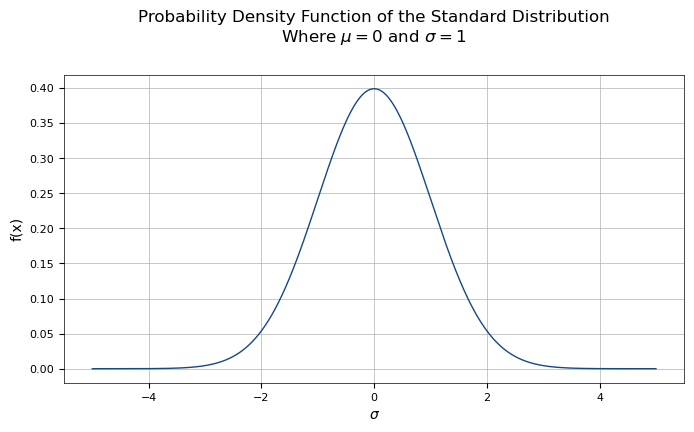

In [27]:
# The Plot of the Standard Normal PDF where $\mu = 10$
# and $\sigma = 1$ in the Real Interval $[-5.0, 5.0]$
# fig:W01_StdNormPDF1

x_axis = normal_x_values
y_axis = normal_distribution.pdf(normal_x_values)

# Plot the result
plot.figure(figsize=(8, 4))

# Format the plot
plot.grid(True, which="both")

# Label the axes
plot.xlabel("$\\sigma$")
plot.ylabel("f(x)")

# Label the plot
plot.title(
    "Probability Density Function of the Standard Distribution\n"
    "Where $\\mu = $"
    + str(mean)
    + " and $\\sigma = $"
    + str(stdev),
    pad=24.0,
)

# Display the graph
plot.plot(x_axis, y_axis)

As before, displaying the CDF is essentially identical to the PDF, apart from the change in `Line 6`. This should give the standard CDF plot in [@fig:W01_StdNormCDF1].

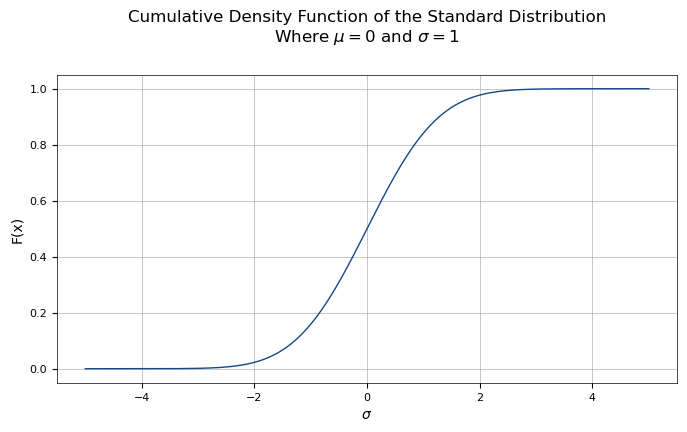

In [28]:
# The Plot of the Standard Normal CDF where $\mu = 10$
# and $\sigma = 1$ in the Real Interval $[-5.0, 5.0]$
# fig:W01_StdNormCDF1

x_axis = normal_x_values
y_axis = normal_distribution.cdf(normal_x_values)

# Plot the result
plot.figure(figsize=(8, 4))

# Format the plot
plot.grid(True, which="both")

# Label the axes
plot.xlabel("$\\sigma$")
plot.ylabel("F(x)")

# Label the plot
plot.title(
    "Cumulative Density Function of the Standard Distribution\n"
    "Where $\\mu = $"
    + str(mean)
    + " and $\\sigma = $"
    + str(stdev),
    pad=24.0,
)

# Display the graph
plot.plot(x_axis, y_axis)

### Creating an Interactive PDF for the Normal Distribution

To explore other values of the normal distribution, outside the standard normal distribution, we will go beyond a static plot. In Jupyter you can animate different variables, using the [Jupyter Widgets](https://ipywidgets.readthedocs.io/en/latest/) library. This require Javascript support, which means it is usually confined to a browser: but Visual Studio Code can cope with these as well.

Import the widgets library as

In [29]:
# Import the widget packages for this Notebook
import ipywidgets as widgets

Now the code for the interactive normal distribution can be created as follows. This is very similar to the charts we have created before, except that the call to `plot` is wrapped in a function called `plot_normal_pdf` (`Line 6`). The `plot_normal_pdf` takes the parameters `mean` and `stdev`, and calculates the PDF using these values. To show the spread of the normal distribution, `plot_normal_pdf` also annotates the mean and first standard deviation in `Line 37` to `Line 58`. Then `Line 64` creates a variable `run_plot` from the Jupyter [`widgets.interact()`](https://ipywidgets.readthedocs.io/en/latest/examples/Using%20Interact.html#using-interact) method, and asking for two sliders to represent the `mean` and `stdev`. Finally `Line 79` calls `run_plot`, which should show the slides and allow you to modify the plot values.

In [30]:
##
## Define the Interactive Function for the Normal PDF
##


def plot_normal_pdf(mean, stdev):
    # Plots the Normal Distribution of with a mean of `mean`,
    # and a standard deviation of `stdev`

    # Calculate the interval between 0 and 20, in steps of 0.001
    x_axis = np.arange(0, 20, 0.001)
    y_axis = sp.stats.norm.pdf(x_axis, mean, stdev)

    # Plot the result
    plot.figure(figsize=(8, 4))
    plot.plot(x_axis, y_axis)

    plot.grid(True, which="both")

    plot.title(
        "Probability Density Function of the Standard"
        " Normal Distribution With\n a Mean of "
        + str(mean)
        + " and Standard Deviation of "
        + str(stdev),
        pad=24.0,
    )
    plot.xlabel("Value")
    plot.ylabel("Relative Likelihood (p)")

    plot.ylim(
        0,
        sp.stats.norm.pdf(mean, mean, stdev) * 1.08,
    )
    plot.xlim(0, 20)

    # Annotate Mean and Standard Deviations
    plot.vlines(
        mean,
        0,
        sp.stats.norm.pdf(mean, mean, stdev),
        color=signal_colours["orange"],
        linestyles="dashed",
    )
    plot.vlines(
        mean - stdev,
        0,
        sp.stats.norm.pdf(mean - stdev, mean, stdev),
        color=signal_colours["orange"],
        linestyles="dotted",
    )
    plot.vlines(
        mean + stdev,
        0,
        sp.stats.norm.pdf(mean + stdev, mean, stdev),
        color=signal_colours["orange"],
        linestyles="dotted",
    )

    plot.show()


# Run the interactive plot
run_plot = widgets.interact(
    plot_normal_pdf,
    mean=widgets.FloatSlider(
        description="Mean",
        min=0,
        max=20,
        value=10,
    ),
    stdev=widgets.FloatSlider(
        description="Standard Deviation",
        min=1,
        max=5,
        value=2,
    ),
)

run_plot

interactive(children=(FloatSlider(value=10.0, description='Mean', max=20.0), FloatSlider(value=2.0, descriptio…

<function __main__.plot_normal_pdf(mean, stdev)>

The interactive version of the CDF plot is essentially identical, apart from the changing the SciPy library calls. Notice that for large standard deviations, or for values of the mean close to the limit, the CDF curve doesn't fit into the 'window' of values we have defined. You can also see how changing the standard deviation causes the plot to 'rotate' about the mean. Whilst changing the mean changes the location of the curve, just as for the PDF plot above. 

In [31]:
##
## Define the Interactive Function for the Normal CDF
##


def plot_normal_cdf(mean, stdev):
    # Plots the Normal Distribution of with a mean of `mean`,
    # and a standard deviation of `stdev`

    # Calculate the interval between 0 and 20, in steps of 0.001
    x_axis = np.arange(0, 20, 0.001)
    y_axis = sp.stats.norm.cdf(x_axis, mean, stdev)

    # Plot the result
    plot.figure(figsize=(8, 4))
    plot.plot(x_axis, y_axis)

    plot.grid(True, which="both")

    plot.title(
        "Cumulative Density Function of the Standard"
        " Normal Distribution With\n a Mean of "
        + str(mean)
        + " and Standard Deviation of "
        + str(stdev),
        pad=24.0,
    )
    plot.xlabel("Value")
    plot.ylabel("Relative Likelihood (p)")

    plot.ylim(0, 1.1)
    plot.xlim(0, 20)

    # Annotate Mean and Standard Deviations
    plot.vlines(
        mean,
        0,
        sp.stats.norm.cdf(mean, mean, stdev),
        color=signal_colours["orange"],
        linestyles="dashed",
    )
    plot.vlines(
        mean - stdev,
        0,
        sp.stats.norm.cdf(mean - stdev, mean, stdev),
        color=signal_colours["orange"],
        linestyles="dotted",
    )
    plot.vlines(
        mean + stdev,
        0,
        sp.stats.norm.cdf(mean + stdev, mean, stdev),
        color=signal_colours["orange"],
        linestyles="dotted",
    )

    plot.show()


# Run the interactive plot
run_plot = widgets.interact(
    plot_normal_cdf,
    mean=widgets.FloatSlider(
        description="Mean",
        min=0,
        max=20,
        value=10,
    ),
    stdev=widgets.FloatSlider(
        description="Standard Deviation",
        min=1,
        max=5,
        value=2,
    ),
)

run_plot

interactive(children=(FloatSlider(value=10.0, description='Mean', max=20.0), FloatSlider(value=2.0, descriptio…

<function __main__.plot_normal_cdf(mean, stdev)>

You can use the sliders to explore both the simple normal distribution, and observe the effect changing the mean and standard deviation has. Note that in our model, the central value _always_ follows the mean (dashed line), and the standard deviation is _always_ symmetric (dotted lines). You can check this by observing the shapes of the PDF and CDF as it changes.



### Extra Mile: Non-Standard Normal Distributions

In 'real' normal distribution we sometimes find the 'central' value is _not_ the mean, but is shifted from the mean. This is called _skew_, and the resulting distributions are _non-central_. You you can explore the effect skew has using the [`scipy.stats.skewnorm`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.skewnorm.html) distribution instead of `scipy.stats.norm` in the code above. Some normal distributions are also 'fatter' or 'thinner' than you would expect, and this is called _kurtosis_. For a given set of data, SciPy can calculate kurtosis using the [`scipy.stats.
kurtosis()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosis.html) method. Similarly the degree of skew can be calculated using [`scipy.stats.skew()`](g/doc/scipy/reference/generated/scipy.stats.skew.html#scipy.stats.skew). 

Try modifying the code above to represent a wider range of normal distributions for both the PDF and CDF. You can start with the [`scipy.stats.skewnorm`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.skewnorm.html) distribution, and add a slider to represent the skew. You will probably also have to modify the limits used by Matplotlib, either dynamically or at least with a larger window. The ['cheatsheets'](https://matplotlib.org/cheatsheets/) for Matplotlib are a good place to start when modifying plots.

## Quantiles and Probabilities

### Calculating Probabilities from the Standard Normal Curve

As we said earlier, a core use of the normal distribution in statistical analysis is to calculate _quantiles_. These 'probability regions' of the normal distribution are used to model both real-world populations, and serve as the core theory for a number of statistical methods. We will look at both uses later^[See _Explanation_ _EC.03_ (Hypothesis Testing) for more uses of the normal distribution in both real-world and statistical modelling. _Explanation_ _EC.02_ (_Samples and Populations_) covers the use of the normal distribution for statistical qualification, especially in the analysis of error and statistical confidence.], for the moment focusing on the calculations themselves.

In general, though, we are interested in two different types of regions for a normal distribution

- **one-tailed** probabilities address questions where a quantity is either _above or _below_ a specified limit on the left **or** the right of the normal distribution
- **two-tailed**_ probabilities address questions where a quantity is either _between_ two limits, or _outside_ those limits on **both** sides of the normal distribution

Knowing the question you want to answer is important for selecting the correct region. For example, some statistical tests are one-tailed, and so _cannot_ address problems where we need to find whether a specific probability lies in a given range on the 'other side' of the distribution. Other tests come in both one-tailed and two-tailed forms, and again, selecting the right kind of statistical test is important for getting an answer that has some validity.

For the following examples, we will use $x$ as the variable of interest in the probability range $P$, where $P \in (0,1]$ (since the normal curve is asymptotic at $P=0$). Specifically we are going to look at two-tailed regions where

1. $P(x \leq 0.4)$

2. $P(x \geq -1.3)$

3. $P(-0.1 \leq x \leq 0.4)$

4. $P(|x| \leq 1.2) = P(-1.2 \leq x \leq 1.2)$

Calculating $P$ for these probabilities can be done using the [`scipy.stats.norm.cdf()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html#scipy.stats.norm) we have just used in the section above. Before we have used the `cdf()` method by passing a _range_ of $x$ values: either `normal_x_values` or the [`np.arange()`](https://numpy.org/doc/stable/reference/generated/numpy.arange.html) method in the interactive plots. However we can also pass in a single value, and SciPy will return the probability calculation for the specified point on the CDF curve. If we look at the definition of the `cdf` method we will also find the parameters are defined as 

```python
cdf(x, loc=0, scale=1)]
```

Since we are looking for probabilities on the _standard normal_ curve, we don't need to specify either `loc` or `scale`. If we needed to, though, we could adjust the probability calculation for the specific mean and standard deviation of the population in questions. 

For our calculations, though, the four probabilities we need are given by
<!-- 
If we have a variable that is distributed according to the standard normal distribution then we can use python to calculate the probability $P$ from the normal distribution. The CDF represents the probability that a random variable from the given distribution will be less than or equal to a specific value.

So the following probabilities for a standard normally distributed variable $x$ can be calculated as shown in code block below:

The code block also shows hwo to use the `pandas` library to shade the appropriate part of the normal PDF that represents the calculated probability -->

In [32]:
# $P(x \leq 0.4)$
p1 = sp.stats.norm.cdf(0.4)
# $P(x \geq -1.3)$
p2 = 1 - sp.stats.norm.cdf(-1.3)
# $P(-0.1 \leq x \leq 0.4)$
p3 = p1 - sp.stats.norm.cdf(-0.1)
# $P(|x| \leq 1.2) = P(-1.2 \leq x \leq 1.2)$
p4 = sp.stats.norm.cdf(1.2) - sp.stats.norm.cdf(-1.2)

print(f"p1: {p1 :.3f}")
print(f"p2: {p2 :.3f}")
print(f"p3: {p3 :.3f}")
print(f"p4: {p4 :.3f}")

p1: 0.655
p2: 0.903
p3: 0.195
p4: 0.770


### Using Sub-Figures to Plot Probabilities 

Plotting these probabilities requires first determining the region of interest. Before we looked at the interval $\pm 5\sigma$, but we will restrict this slightly to $\pm 3\sigma$ for the four regions

In [33]:
# Generate the values for the x-axis between -3.0 and 3.0
# standard deviations
normal_x_values = np.linspace(-3.0, 3.0, 100000)

Next we need the PDF of the standard normal distribution, calculated over the $x$ axis range, `normal_x_values`, as before. Since this is the standard normal distribution, we can ignore `loc` and `scale`

In [34]:
# Create probability density function (PDF)
std_normal_pdf = sp.stats.norm.pdf(normal_x_values)

We want to plot the four plots together, so we will use a feature of Matplotlib called [subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html). Here `figure` will hold the final plot image, and `subfig` will hold the individual plots. The individual plots will behave in exactly the same way as before: all we are doing here is effectively creating an array of them

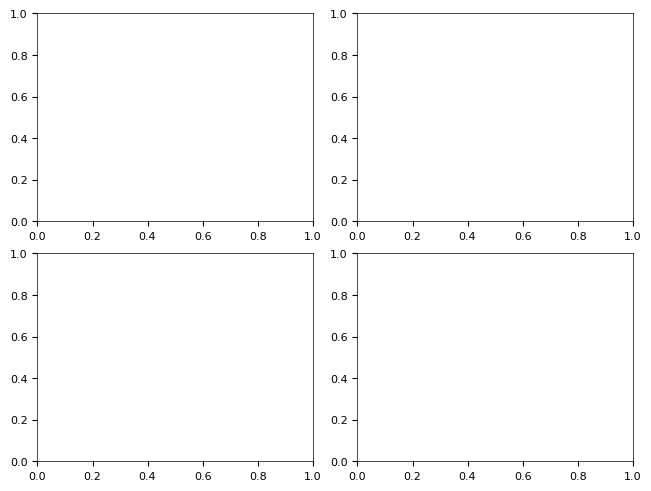

In [35]:
figure, subfig = plot.subplots(
    ncols=2,
    nrows=2,
    layout="constrained",
)

To the blank set of plots, we now want to add the standard normal curves. This uses the `normal_x_values` and `std_normal_pdf` values we have just calculated. Since we are walking over the 2x2 array, we will also use this opportunity to set $x$ and $y$ axis labels for the left-most and bottom plots. We are using the `constrained` layout to save space in the figure, so this avoids having to add axis values where we don't need them (and where it is still clear what the plot represents)

In [36]:
for row in range(2):
    for col in range(2):
        subfig[row, col].plot(
            normal_x_values, std_normal_pdf
        )
        if row == 1:
            subfig[row, col].set_xlabel("Values")
        if col == 0:
            subfig[row, col].set_ylabel(
                "Probability Density"
            )

With the standard normal distributions in place, we need to calculate (and plot) the regions of interest. To do this we will iterate back through the 2x2 array of figures, and set-up each sub-figure again.

We have already seen the [`set_title()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.set_title.html) method for other plots, as the `title` method. Each sub-plot behaves as an independent axis in `figure`, and is configured via the [`Axes` class](https://matplotlib.org/stable/api/axes_api.html)^[The class name chosen by Matplotlib for sub-figures isn't that intuitive, and so we have chosen '`subfig`' as the object name referring to 'regions of `figure`'. In many examples, you will see these 'sub-figures' given object names such as '`axes`', or '`axs`' after the class name. They all refer to the same `Axes` class.]. So we have to use the methods of the `Axes` class to add a title to show the region of interest (`Line 6`, `Line 17`, `Line 28` and `Line 40`). This is why we also have to use [`matplotlib.axes.Axes.set_ylim()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.set_ylim.html#matplotlib.axes.Axes.set_ylim`) method in `Line 14`, instead of the normal `ylim()` method we used previously. Both do the same job, but `set_ylim()` applies to sub-figures and not figures.

Of more interest is the [`matplotlib.pyplot.fill_between()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.fill_between.html) method. The first arguments of `fill_between()` are the values of the $x$ and $y$ axes; which by default will just colour in the full plot. However we can also pass in an array of Boolean arguments as in `Line 11`, `Line 22`, `Line 33--34` and `Line 45--46`. These arguments tell Matplotlib to _only_ colour the chart if the specified conditions are true. So we can now add the two probabilities, and two probability ranges, and we should get coloured regions shown in [@fig:W01_StdNormQuartile].

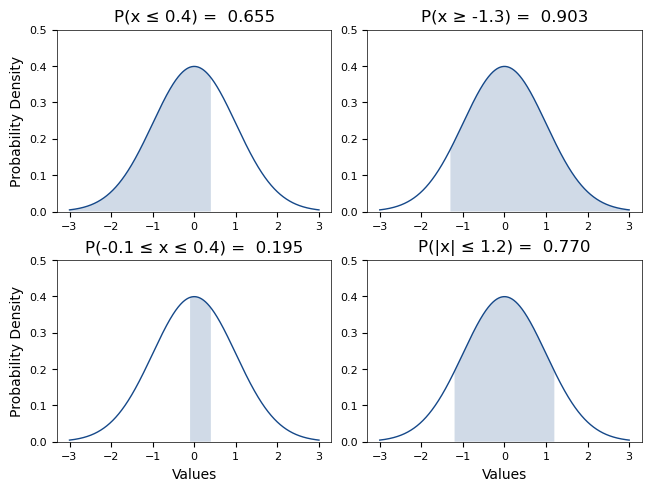

In [37]:
# A Plot of Four Quantiles, Showing the Regions Defined by
# Four Probabilities on the Standard Normal PDF
# fig:W01_StdNormQuartile

# Create the sub-figure plot for p1
subfig[0, 0].set_title(f"P(x ≤ 0.4) = {p1: .3f}")

subfig[0, 0].fill_between(
    normal_x_values,
    std_normal_pdf,
    alpha=0.2,
    where=(normal_x_values <= 0.4),
)

subfig[0, 0].set_ylim(0, 0.5)

# Create the sub-figure plot for p2
subfig[0, 1].set_title(f"P(x ≥ -1.3) = {p2: .3f}")

subfig[0, 1].fill_between(
    normal_x_values,
    std_normal_pdf,
    alpha=0.2,
    where=(normal_x_values >= -1.3),
)

subfig[0, 1].set_ylim(0, 0.5)

# Create the sub-figure plot for p3
subfig[1, 0].set_title(f"P(-0.1 ≤ x ≤ 0.4) = {p3: .3f}")

subfig[1, 0].fill_between(
    normal_x_values,
    std_normal_pdf,
    alpha=0.2,
    where=(normal_x_values <= 0.4)
    & (normal_x_values >= -0.1),
)

subfig[1, 0].set_ylim(0, 0.5)

# Create the sub-figure plot for p4
subfig[1, 1].set_title(f"P(|x| ≤ 1.2) = {p4: .3f}")

subfig[1, 1].fill_between(
    normal_x_values,
    std_normal_pdf,
    alpha=0.2,
    where=(normal_x_values <= 1.2)
    & (normal_x_values >= -1.2),
)

subfig[1, 1].set_ylim(0, 0.5)

# Plot the final figure
figure

\clearpage

## Questions

Use Python to answer the following questions. Where appropriate give answers to 4 decimal places.

1. Given a normal  distribution with $\mu = 10$ and $\sigma = 2$

    a. Plot the quantiles and $P$ values for the following regions

      - $P(|x| <= \sigma)$
      - $P(|x| <= 2\sigma)$
      - $P(|x| <= 3\sigma)$
      - $P(\mu\ \,<= x <= \sigma)$
  
    b. How do the $P$ values above relate to the expected values for the area under a standard normal curve? 

*Answer to 1(a)*:

In [38]:
# code for question 1(a)

*Answer to 1(b)*

<!-- Markdown here />

2. The lifetime $T$ of a particular model of battery is normally distributed with an average lifetime of 825 hours and a variance of 900 hours. Using Python can you answer the following - illustrating your answers by shading the pdf:

    a. What is the probability that a battery lasts at least 900 hrs?  
    b. What is the probability that a battery last less than 800 hours?  
    c. What is the probability that the lifetime of a battery is between 810 and 870 hours?  


In [ ]:
# code for question 2(a) -- 2(c)

3. The resistance of a 10% $1 \text{k}\Omega$ is modelled using a normal distribution where the 10% is assumed to 95% of the distribution. 

    a. What is the standard deviation for the model?  
    b. Using Python, what is the probability that the measured resistance $R$ will be less than $950 \Omega$?  
    c. What is the probability $R \geq 1.1\text{k}\Omega$?  
    d. What is the probability $R$ will be between 0.98 & 1.02k$\Omega$?  

*Answer*: 

In [40]:
# code for question 3(b) -- 3(d)

## References